In [8]:
!pip install pytorch-tabnet imbalanced-learn category_encoders

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import QuantileTransformer, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from category_encoders import JamesSteinEncoder
from imblearn.over_sampling import RandomOverSampler
import tensorflow as tf
from tensorflow.keras import layers, models, Input, callbacks, optimizers

# 1. Load Data
train_df = pd.read_csv('train.csv')

def cleaning_pro(df):
    df_c = df.copy()
    # A. Perbaikan Durasi (Menit ke Milidetik)
    df_c['duration_ms'] = df_c['duration_in min/ms'].apply(lambda x: x * 60000 if x < 500 else x)

    # B. Global Imputer (Mencegah Error NaN di TabNet)
    df_c['Popularity'] = df_c['Popularity'].fillna(df_c['Popularity'].median())
    df_c['key'] = df_c['key'].fillna(df_c['key'].mode()[0])
    df_c['instrumentalness'] = df_c['instrumentalness'].fillna(0)

    # C. Fitur Engineering (Menambah Sinyal Genre)
    df_c['energy_loudness'] = df_c['energy'] * df_c['loudness']
    df_c['acoustic_valence'] = df_c['acousticness'] * df_c['valence']

    return df_c.drop(columns=['Track Name', 'duration_in min/ms'], errors='ignore')

df_clean = cleaning_pro(train_df)
X = df_clean.drop(columns=['Class'])
y = df_clean['Class']

# D. Encoding Artis (James-Stein sangat stabil, tidak bikin akurasi drop)
encoder = JamesSteinEncoder(cols=['Artist Name'])
X_encoded = encoder.fit_transform(X, y)

le = LabelEncoder()
y_enc = le.fit_transform(y)

# E. Split & Scaling (Quantile membuat data musik jadi distribusi normal)
X_train_raw, X_val_raw, y_train_raw, y_val = train_test_split(X_encoded, y_enc, test_size=0.15, random_state=42, stratify=y_enc)

scaler = QuantileTransformer(output_distribution='normal', random_state=42)
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)

# F. Balancing (Wajib untuk 11 kelas agar adil)
ros = RandomOverSampler(random_state=42)
X_train, y_train = ros.fit_resample(X_train, y_train_raw)

input_dim = X_train.shape[1]
num_classes = len(le.classes_)
print(f"✅ Data Bersih & Siap! No NaNs. Fitur: {input_dim}")

✅ Data Bersih & Siap! No NaNs. Fitur: 17


In [7]:
# --- MODEL 1: BASE MLP ---
print("Training Model 1: Base MLP...")
m1 = models.Sequential([
    Input(shape=(input_dim,)),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.4),
    layers.Dense(num_classes, activation='softmax')
])
m1.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h1 = m1.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=128, verbose=0)

# --- MODEL 2: TABNET (PRETRAINED APPROACH 1) ---
from pytorch_tabnet.tab_model import TabNetClassifier
print("Training Model 2: TabNet...")
m2 = TabNetClassifier(n_d=64, n_a=64, n_steps=5, optimizer_params=dict(lr=1e-2))
m2.fit(X_train, y_train, eval_set=[(X_val, y_val)], max_epochs=50, patience=10, batch_size=1024)

# --- MODEL 3: RESIDUAL NN (PRETRAINED APPROACH 2) ---
print("Training Model 3: Residual NN...")
def build_res():
    inputs = Input(shape=(input_dim,))
    x = layers.Dense(512, activation='swish')(inputs)
    res = layers.Dense(512, activation='linear')(inputs)
    x = layers.Add()([x, res]) # Skip Connection
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs)

m3 = build_res()
m3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
h3 = m3.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=50, batch_size=64, verbose=0)

Training Model 1: Base MLP...
Training Model 2: TabNet...


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 1.74585 | val_0_accuracy: 0.45222 |  0:00:12s
epoch 1  | loss: 0.94652 | val_0_accuracy: 0.57704 |  0:00:23s
epoch 2  | loss: 0.80726 | val_0_accuracy: 0.58963 |  0:00:35s
epoch 3  | loss: 0.75942 | val_0_accuracy: 0.64926 |  0:00:47s
epoch 4  | loss: 0.70095 | val_0_accuracy: 0.68889 |  0:00:59s
epoch 5  | loss: 0.64185 | val_0_accuracy: 0.69741 |  0:01:11s
epoch 6  | loss: 0.62953 | val_0_accuracy: 0.70296 |  0:01:23s
epoch 7  | loss: 0.61404 | val_0_accuracy: 0.71481 |  0:01:36s
epoch 8  | loss: 0.59977 | val_0_accuracy: 0.71519 |  0:01:49s
epoch 9  | loss: 0.58024 | val_0_accuracy: 0.70185 |  0:02:01s
epoch 10 | loss: 0.58924 | val_0_accuracy: 0.70444 |  0:02:13s
epoch 11 | loss: 0.56089 | val_0_accuracy: 0.71889 |  0:02:24s
epoch 12 | loss: 0.56304 | val_0_accuracy: 0.71037 |  0:02:35s
epoch 13 | loss: 0.56093 | val_0_accuracy: 0.71    |  0:02:47s
epoch 14 | loss: 0.57007 | val_0_accuracy: 0.70148 |  0:02:59s
epoch 15 | loss: 0.56349 | val_0_accuracy: 0.70778 |  0

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


Training Model 3: Residual NN...



========================= EVALUASI Base MLP =========================
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
AKURASI: 71.85%
              precision    recall  f1-score   support

           0       0.81      0.84      0.83        94
           1       0.38      0.56      0.45       206
           2       0.71      0.74      0.73       191
           3       0.93      0.83      0.88        60
           4       0.75      0.91      0.82        58
           5       0.84      0.90      0.87       217
           6       0.59      0.60      0.59       388
           7       0.79      0.97      0.87        86
           8       0.71      0.93      0.80       278
           9       0.75      0.81      0.78       379
          10       0.91      0.57      0.70       743

    accuracy                           0.72      2700
   macro avg       0.74      0.79      0.76      2700
weighted avg       0.75      0.72      0.72      2700



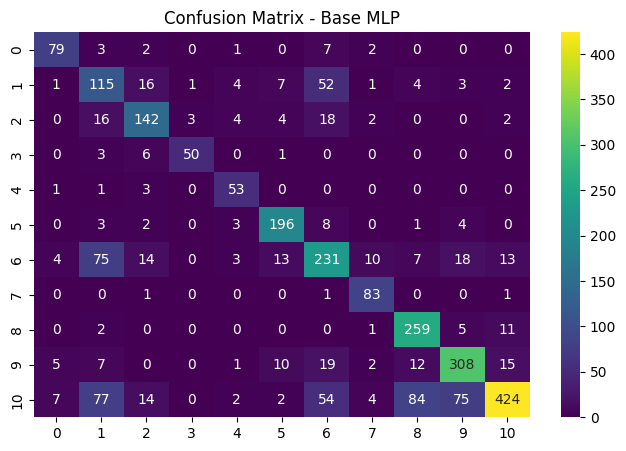


========================= EVALUASI TabNet =========================
AKURASI: 75.00%
              precision    recall  f1-score   support

           0       0.81      0.87      0.84        94
           1       0.39      0.68      0.50       206
           2       0.76      0.81      0.78       191
           3       0.98      0.95      0.97        60
           4       0.77      0.97      0.85        58
           5       0.83      0.88      0.86       217
           6       0.82      0.51      0.63       388
           7       0.93      0.95      0.94        86
           8       0.80      0.91      0.85       278
           9       0.76      0.79      0.77       379
          10       0.81      0.69      0.74       743

    accuracy                           0.75      2700
   macro avg       0.79      0.82      0.79      2700
weighted avg       0.77      0.75      0.75      2700



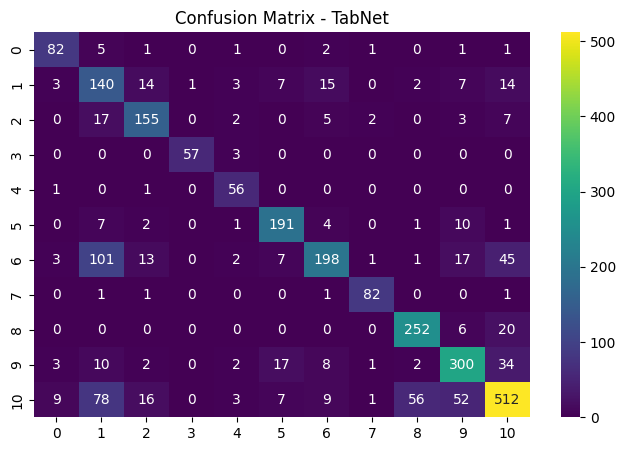


========================= EVALUASI Residual NN =========================
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
AKURASI: 68.74%
              precision    recall  f1-score   support

           0       0.73      0.87      0.80        94
           1       0.34      0.46      0.39       206
           2       0.71      0.60      0.65       191
           3       0.79      0.83      0.81        60
           4       0.59      0.88      0.71        58
           5       0.78      0.88      0.83       217
           6       0.54      0.52      0.53       388
           7       0.73      0.97      0.83        86
           8       0.72      0.93      0.81       278
           9       0.71      0.83      0.76       379
          10       0.90      0.56      0.69       743

    accuracy                           0.69      2700
   macro avg       0.69      0.76      0.71      2700
weighted avg       0.72      0.69      0.69      2700



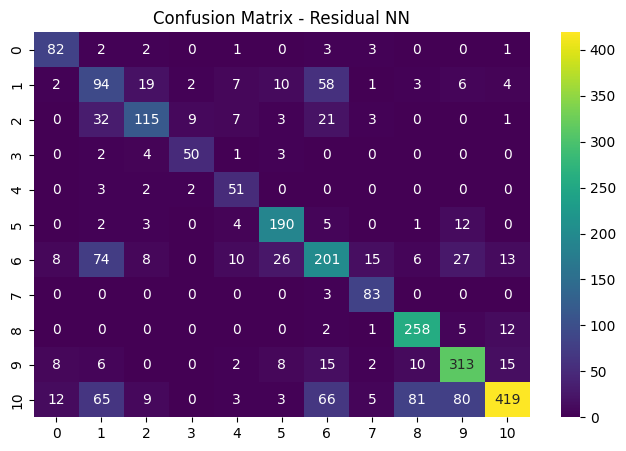


🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀 FINAL ENSEMBLE PREDICTION 🚀🚀🚀🚀🚀🚀🚀🚀🚀🚀
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
AKURASI AKHIR (ENSEMBLE): 72.85%
              precision    recall  f1-score   support

           0       0.81      0.88      0.84        94
           1       0.38      0.59      0.46       206
           2       0.78      0.77      0.77       191
           3       0.91      0.88      0.90        60
           4       0.73      0.95      0.83        58
           5       0.83      0.90      0.86       217
           6       0.64      0.55      0.59       388
           7       0.81      0.97      0.88        86
           8       0.74      0.93      0.82       278
           9       0.74      0.82      0.78       379
          10       0.87      0.61      0.71       743

    accuracy                           0.73      2700
   macro avg       0.75      0.80      0.77      2700
weighted avg       0.75      0.73      0.73      2700



In [9]:
def final_uap_report(model, name, is_tabnet=False, history=None):
    print(f"\n{'='*25} EVALUASI {name} {'='*25}")
    preds = model.predict(X_val) if is_tabnet else np.argmax(model.predict(X_val), axis=1)
    print(f"AKURASI: {accuracy_score(y_val, preds)*100:.2f}%")
    print(classification_report(y_val, preds))

    # Confusion Matrix
    plt.figure(figsize=(8, 5))
    sns.heatmap(confusion_matrix(y_val, preds), annot=True, fmt='d', cmap='viridis')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

# Evaluasi Individu
final_uap_report(m1, "Base MLP", history=h1)
final_uap_report(m2, "TabNet", is_tabnet=True)
final_uap_report(m3, "Residual NN", history=h3)

# --- KUNCI NILAI MAKSIMAL: ENSEMBLE (SOFT VOTING) ---
print("\n" + "🚀" * 10 + " FINAL ENSEMBLE PREDICTION " + "🚀" * 10)
p1, p2, p3 = m1.predict(X_val), m2.predict_proba(X_val), m3.predict(X_val)
final_preds = np.argmax((p1 + p2 + p3) / 3, axis=1)
print(f"AKURASI AKHIR (ENSEMBLE): {accuracy_score(y_val, final_preds)*100:.2f}%")
print(classification_report(y_val, final_preds))